In [5]:
import pandas as pd

def show_cols(path):
    try:
        df = pd.read_csv(path)
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="latin1")
    print(f"\n==== {path} ====")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head(3))
    return df

gdp_raw       = show_cols("GDP_Component.csv")
emp_raw       = show_cols("labor_force.csv")
pop_raw       = show_cols("population.csv")
cpi_raw       = show_cols("Inflation.csv")


==== GDP_Component.csv ====
shape: (4402, 17)
columns: ['REF_DATE', 'GEO', 'DGUID', 'Prices', 'Seasonal adjustment', 'Estimates', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


,REF_DATE,GEO,DGUID,Prices,Seasonal adjustment,Estimates,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1990-01,Canada,2016A000011124,Chained (2017) dollars,Seasonally adjusted at annual rates,Final consumption expenditure,Dollars,81,millions,6,v62305723,1.1.1.1,892824,NaN,NaN,NaN,0
1,1990-04,Canada,2016A000011124,Chained (2017) dollars,Seasonally adjusted at annual rates,Final consumption expenditure,Dollars,81,millions,6,v62305723,1.1.1.1,882793,NaN,NaN,NaN,0
2,1990-07,Canada,2016A000011124,Chained (2017) dollars,Seasonally adjusted at annual rates,Final consumption expenditure,Dollars,81,millions,6,v62305723,1.1.1.1,888741,NaN,NaN,NaN,0



==== labor_force.csv ====
shape: (495, 19)
columns: ['REF_DATE', 'GEO', 'DGUID', 'Labour force characteristics', 'Gender', 'Age group', 'Statistics', 'Data type', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


,REF_DATE,GEO,DGUID,Labour force characteristics,Gender,Age group,Statistics,Data type,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2025-05,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,34530.6,NaN,NaN,NaN,1
1,2025-06,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,34577.2,NaN,NaN,NaN,1
2,2025-07,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,34614.8,NaN,NaN,NaN,1



==== population.csv ====
shape: (1962, 14)
columns: ['REF_DATE', 'GEO', 'DGUID', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


,REF_DATE,GEO,DGUID,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1990-01,Canada,2021A000011124,Persons,249,units,0,v1,1,27463550,NaN,NaN,NaN,0
1,1990-04,Canada,2021A000011124,Persons,249,units,0,v1,1,27567161,NaN,NaN,NaN,0
2,1990-07,Canada,2021A000011124,Persons,249,units,0,v1,1,27691138,NaN,NaN,NaN,0



==== Inflation.csv ====
shape: (4455, 15)
columns: ['REF_DATE', 'GEO', 'DGUID', 'Products and product groups', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


,REF_DATE,GEO,DGUID,Products and product groups,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1992-01,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690914,1.1,83.1,NaN,NaN,NaN,1
1,1992-02,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690914,1.1,83.2,NaN,NaN,NaN,1
2,1992-03,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690914,1.1,83.6,NaN,NaN,NaN,1


In [ ]:



g = pd.read_csv("GDP_Component.csv")


g = g[
    (g["GEO"] == "Canada") &
    (g["Prices"] == "Chained (2017) dollars") &
    (g["Seasonal adjustment"] == "Seasonally adjusted at annual rates")
].copy()


keep_ests = [
    "Final consumption expenditure",
    "Gross fixed capital formation",
    "General governments final consumption expenditure",
    "Exports of goods and services",
    "Less: imports of goods and services",
]
g = g[g["Estimates"].isin(keep_ests)].copy()


g_wide = (
    g.pivot(index="REF_DATE", columns="Estimates", values="VALUE")
      .reset_index()
)


required = {
    "Final consumption expenditure",
    "Gross fixed capital formation",
    "General governments final consumption expenditure",
    "Exports of goods and services",
    "Less: imports of goods and services",
}
missing = required.difference(g_wide.columns)
assert not missing, f"Missing components: {missing}"

g_wide["gdp_block_level"] = (
    g_wide["Final consumption expenditure"]
  + g_wide["Gross fixed capital formation"]
  + g_wide["General governments final consumption expenditure"]
  + g_wide["Exports of goods and services"]
  - g_wide["Less: imports of goods and services"]
)


y = g_wide["REF_DATE"].str.slice(0,4).astype(int)
m = g_wide["REF_DATE"].str.slice(5,7).astype(int)
q = m.map({1:1, 4:2, 7:3, 10:4})
g_wide["date"] = pd.PeriodIndex(y.astype(str) + "Q" + q.astype(str), freq="Q")


gdp_q = (
    g_wide[["date", "gdp_block_level"]]
      .sort_values("date")
      .groupby("date", as_index=False)
      .first()
)

gdp_q["gdp_block_growth"] = 100 * np.log(gdp_q["gdp_block_level"]).diff(1)

print("Rows:", len(gdp_q), "| Start:", gdp_q["date"].min(), "| End:", gdp_q["date"].max())
print(gdp_q.head(3)); print(gdp_q.tail(3))

gdp_q.to_csv("gdp_quarterly_clean.csv", index=False)

Rows: 142 | Start: 1990Q1 | End: 2025Q2
Estimates    date  gdp_block_level  gdp_block_growth
0          1990Q1          1464292               NaN
1          1990Q2          1453049         -0.770774
2          1990Q3          1461748          0.596887
Estimates    date  gdp_block_level  gdp_block_growth
139        2024Q4          2994610          1.413058
140        2025Q1          2992430         -0.072824
141        2025Q2          2975227         -0.576543


In [12]:
cpi_raw.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Products and product groups', 'UOM',
       'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE',
       'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='object')

In [ ]:

cpi = pd.read_csv("Inflation.csv")[["REF_DATE", "GEO", "Products and product groups", "VALUE"]]
cpi = cpi[(cpi["GEO"] == "Canada") & (cpi["Products and product groups"] == "All-items")].copy()


cpi["REF_DATE"] = pd.to_datetime(cpi["REF_DATE"])
cpi = cpi.sort_values("REF_DATE").set_index("REF_DATE").rename(columns={"VALUE": "CPI"})


infl_mom = (np.log(cpi["CPI"]) - np.log(cpi["CPI"].shift(1))) * 100

infl_yoy = (np.log(cpi["CPI"]) - np.log(cpi["CPI"].shift(12))) * 100

iq_mom = infl_mom.dropna().resample("Q").mean()
iq_yoy = infl_yoy.dropna().resample("Q").mean()

iq_mom.index = iq_mom.index.to_period("Q")
iq_yoy.index = iq_yoy.index.to_period("Q")

C:\Users\logc0\AppData\Local\Temp\ipykernel_14244\465690651.py:17: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  iq_mom = infl_mom.dropna().resample("Q").mean()
C:\Users\logc0\AppData\Local\Temp\ipykernel_14244\465690651.py:18: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  iq_yoy = infl_yoy.dropna().resample("Q").mean()


In [15]:
cpi.head()

,GEO,Products and product groups,CPI
REF_DATE,,,
1992-01-01,Canada,All-items,83.1
1992-02-01,Canada,All-items,83.2
1992-03-01,Canada,All-items,83.6
1992-04-01,Canada,All-items,83.7
1992-05-01,Canada,All-items,83.9


In [28]:
gdp_q.head()

Estimates,gdp_block_level,gdp_block_growth
date,,
1990Q1,1464292,NaN
1990Q2,1453049,-0.770774
1990Q3,1461748,0.596887
1990Q4,1453716,-0.550994
1991Q1,1434553,-1.326973


In [17]:
gdp_q["date"] = pd.PeriodIndex(gdp_q["date"], freq="Q")
gdp_q = gdp_q.set_index("date")

In [19]:
emp_raw.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Labour force characteristics', 'Gender',
       'Age group', 'Statistics', 'Data type', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='object')

In [ ]:

emp = emp_raw.copy()

emp = emp[
    (emp['GEO'] == 'Canada') &
    (emp['Gender'] == 'Total - Gender') &
    (emp['Age group'] == '15 years and over') &
    (emp['Statistics'] == 'Estimate') &
    (emp['Data type'] == 'Seasonally adjusted')
]


emp['REF_DATE'] = pd.to_datetime(emp['REF_DATE'])

emp = emp[['REF_DATE', 'Labour force characteristics', 'VALUE']]


emp_wide = emp.pivot(index='REF_DATE', columns='Labour force characteristics', values='VALUE')


emp_wide.columns.name = None
emp_wide = emp_wide.rename(columns={
    'Population': 'population_level',
    'Labour force': 'labour_force_level',
    'Employment': 'employment_level',
    'Unemployment': 'unemployment_level',
})


emp_wide = emp_wide.sort_index()

emp_wide.tail()

,employment_level,Employment rate,Full-time employment,labour_force_level,Part-time employment,Participation rate,population_level,unemployment_level,Unemployment rate
REF_DATE,,,,,,,,,
2025-05-01,20978.1,60.8,17193.4,22552.7,3784.8,65.3,34530.6,1574.6,7.0
2025-06-01,21061.2,60.9,17206.9,22613.7,3854.3,65.4,34577.2,1552.5,6.9
2025-07-01,21020.4,60.7,17155.9,22580.7,3864.6,65.2,34614.8,1560.2,6.9
2025-08-01,20954.9,60.5,17149.9,22549.5,3804.9,65.1,34644.2,1594.6,7.1
2025-09-01,21015.3,60.6,17256.0,22621.8,3759.3,65.2,34671.9,1606.5,7.1


In [ ]:

pop = pop_raw.copy()


pop = pop[['REF_DATE', 'VALUE']]


pop['REF_DATE'] = pd.to_datetime(pop['REF_DATE'], format='%Y-%m')


pop = pop.rename(columns={'VALUE': 'population_quarterly'})


pop = pop.sort_values('REF_DATE')

pop.set_index('REF_DATE', inplace=True)


pop.tail()


,population_quarterly
REF_DATE,
2025-01-01,865945
2025-01-01,548842
2025-01-01,1089187
2025-01-01,1505644
2025-01-01,41651


In [22]:
emp_wide.tail()

,employment_level,Employment rate,Full-time employment,labour_force_level,Part-time employment,Participation rate,population_level,unemployment_level,Unemployment rate
REF_DATE,,,,,,,,,
2025-05-01,20978.1,60.8,17193.4,22552.7,3784.8,65.3,34530.6,1574.6,7.0
2025-06-01,21061.2,60.9,17206.9,22613.7,3854.3,65.4,34577.2,1552.5,6.9
2025-07-01,21020.4,60.7,17155.9,22580.7,3864.6,65.2,34614.8,1560.2,6.9
2025-08-01,20954.9,60.5,17149.9,22549.5,3804.9,65.1,34644.2,1594.6,7.1
2025-09-01,21015.3,60.6,17256.0,22621.8,3759.3,65.2,34671.9,1606.5,7.1


In [23]:
emp_q = emp_wide[['Unemployment rate']].resample("Q").mean()
emp_q.index = emp_q.index.to_period("Q")

C:\Users\logc0\AppData\Local\Temp\ipykernel_14244\3935596584.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  emp_q = emp_wide[['Unemployment rate']].resample("Q").mean()


In [24]:
pop.index = pop.index.to_period("Q")

In [29]:
print(gdp_q.columns)

Index(['gdp_block_level', 'gdp_block_growth'], dtype='object', name='Estimates')


In [30]:
df_var = (
    gdp_q[["gdp_block_growth"]]
    .merge(iq_yoy.rename("cpi_infl_yoy"), left_index=True, right_index=True)
    .merge(emp_q.rename(columns={"Unemployment rate": "u_rate"}), left_index=True, right_index=True)
    .merge(pop, left_index=True, right_index=True)
)

In [32]:
df_var.head()

,gdp_block_growth,cpi_infl_yoy,u_rate,population_quarterly


In [33]:
print(gdp_q.index)
print(iq_yoy.index)
print(emp_q.index)
print(pop.index)

PeriodIndex(['1990Q1', '1990Q2', '1990Q3', '1990Q4', '1991Q1', '1991Q2',
             '1991Q3', '1991Q4', '1992Q1', '1992Q2',
             ...
             '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2',
             '2024Q3', '2024Q4', '2025Q1', '2025Q2'],
            dtype='period[Q-DEC]', name='date', length=142)
PeriodIndex(['1993Q1', '1993Q2', '1993Q3', '1993Q4', '1994Q1', '1994Q2',
             '1994Q3', '1994Q4', '1995Q1', '1995Q2',
             ...
             '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3',
             '2024Q4', '2025Q1', '2025Q2', '2025Q3'],
            dtype='period[Q-DEC]', name='REF_DATE', length=131)
PeriodIndex(['2025Q2', '2025Q3'], dtype='period[Q-DEC]', name='REF_DATE')
PeriodIndex(['1990Q1', '1990Q1', '1990Q1', '1990Q1', '1990Q1', '1990Q1',
             '1990Q1', '1990Q1', '1990Q1', '1990Q1',
             ...
             '2025Q1', '2025Q1', '2025Q1', '2025Q1', '2025Q1', '2025Q1',
             '2025Q1', '2025Q1', '2025Q1', '20

In [ ]:

df = pd.read_csv("unemployment.csv")


df.columns = ['date', 'unemployment']


df['date'] = pd.to_datetime(df['date'])


df['unemployment'] = pd.to_numeric(df['unemployment'], errors='coerce')


df = df.dropna(subset=['unemployment'])


df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q')


quarterly_avg = df.groupby('quarter')['unemployment'].mean().reset_index()


yearly_avg = df.groupby('year')['unemployment'].mean().reset_index()


print("Quarterly Average Unemployment Rate:")
print(quarterly_avg)

print("\nYearly Average Unemployment Rate:")
print(yearly_avg)


Quarterly Average Unemployment Rate:
    quarter  unemployment
0    1955Q1      4.800000
1    1955Q2      4.433333
2    1955Q3      4.066667
3    1955Q4      3.833333
4    1956Q1      3.700000
..      ...           ...
278  2024Q3      6.566667
279  2024Q4      6.733333
280  2025Q1      6.633333
281  2025Q2      6.933333
282  2025Q3      7.033333

[283 rows x 2 columns]

Yearly Average Unemployment Rate:
    year  unemployment
0   1955      4.283333
1   1956      3.300000
2   1957      4.750000
3   1958      7.133333
4   1959      5.875000
..   ...           ...
66  2021      7.483333
67  2022      5.250000
68  2023      5.383333
69  2024      6.375000
70  2025      6.866666

[71 rows x 2 columns]


In [37]:
gdp_q.head()

Estimates,gdp_block_level,gdp_block_growth
date,,
1990Q1,1464292,NaN
1990Q2,1453049,-0.770774
1990Q3,1461748,0.596887
1990Q4,1453716,-0.550994
1991Q1,1434553,-1.326973


In [56]:
cpi.head()

,GEO,Products and product groups,CPI
REF_DATE,,,
1992-01-01,Canada,All-items,83.1
1992-02-01,Canada,All-items,83.2
1992-03-01,Canada,All-items,83.6
1992-04-01,Canada,All-items,83.7
1992-05-01,Canada,All-items,83.9


In [39]:
pop.head()

,population_quarterly
REF_DATE,
1990Q1,27463550
1990Q1,1011429
1990Q1,130336
1990Q1,3247419
1990Q1,737307


In [42]:
quarterly_avg.head()

,quarter,unemployment
0,1955Q1,4.800000
1,1955Q2,4.433333
2,1955Q3,4.066667
3,1955Q4,3.833333
4,1956Q1,3.700000


In [ ]:

pop_use = pop.copy()


pop_use.reset_index(inplace=True)


pop_use['quarter'] = pop_use['REF_DATE'].dt.to_period('Q').astype(str)


pop_quarterly = pop_use.groupby('quarter', as_index=False)['population_quarterly'].sum()


print(pop_quarterly.head())

  quarter  population_quarterly
0  1990Q1              54869230
1  1990Q2              55075850
2  1990Q3              55323339
3  1990Q4              55555891
4  1991Q1              55650011


In [ ]:

gdp_q = gdp_q.reset_index()


gdp_q = gdp_q.rename(columns={"date": "quarter"})


print(gdp_q.head())

Estimates quarter  gdp_block_level  gdp_block_growth
0          1990Q1          1464292               NaN
1          1990Q2          1453049         -0.770774
2          1990Q3          1461748          0.596887
3          1990Q4          1453716         -0.550994
4          1991Q1          1434553         -1.326973


In [ ]:

cpi_use = cpi.copy()

cpi_use.reset_index(inplace=True)


cpi_use['quarter'] = cpi_use['REF_DATE'].dt.to_period('Q').astype(str)


cpi_quarterly = cpi_use.groupby('quarter', as_index=False)['CPI'].mean()


print(cpi_quarterly.head())

  quarter        CPI
0  1992Q1  83.300000
1  1992Q2  83.900000
2  1992Q3  84.200000
3  1992Q4  84.533333
4  1993Q1  85.100000


In [70]:
gdp_q['quarter'] = gdp_q['quarter'].astype(str)
quarterly_avg['quarter'] = quarterly_avg['quarter'].astype(str)
cpi_quarterly['quarter'] = cpi_quarterly['quarter'].astype(str)
pop_quarterly['quarter'] = pop_quarterly['quarter'].astype(str)


df_var = (
    gdp_q[['quarter', 'gdp_block_growth']]
    .merge(quarterly_avg, on='quarter', how='inner')
    .merge(cpi_quarterly, on='quarter', how='inner')
    .merge(pop_quarterly, on='quarter', how='inner')
)


print(df_var.head())

  quarter  gdp_block_growth  unemployment        CPI  population_quarterly
0  1992Q1          0.146284      10.60000  83.300000              56362954
1  1992Q2         -0.365255      11.00000  83.900000              56539398
2  1992Q3          0.535002      11.53333  84.200000              56742528
3  1992Q4          1.019903      11.73333  84.533333              56948354
4  1993Q1         -0.366350      11.13333  85.100000              57067204


In [73]:
df_var_transformed = df_var.copy()

for col in df_var.columns:
    if col == 'quarter' or col == 'gdp_block_growth':
        continue
    df_var_transformed[col] = np.log(df_var[col]).diff()
    
df_var_transformed = df_var_transformed.dropna().reset_index(drop=True)


In [74]:
df_var_transformed.head()

,quarter,gdp_block_growth,unemployment,CPI,population_quarterly
0,1992Q2,-0.365255,0.037041,0.007177,0.003126
1,1992Q3,0.535002,0.047346,0.003569,0.003586
2,1992Q4,1.019903,0.017192,0.003951,0.003621
3,1993Q1,-0.366350,-0.052490,0.006681,0.002085
4,1993Q2,0.697850,0.043931,0.003129,0.002355


In [ ]:
from statsmodels.tsa.api import VAR
Y_use = df_var_transformed.drop(columns=["quarter"])


Y_use.tail()

,gdp_block_growth,unemployment,CPI,population_quarterly
127,0.954137,0.028655,0.004185,0.006326
128,0.525371,0.065597,0.005414,0.006505
129,0.950622,0.041457,0.004765,0.006615
130,1.413058,0.025064,0.004537,0.005602
131,-0.072824,-0.014963,0.007584,0.001935


In [ ]:

T, k = len(Y_use), Y_use.shape[1]
p_cap = max(1, min(8, int((T - 2) // (k + 1))))


sel = VAR(Y_use).select_order(maxlags=p_cap)
p = int(max(1, sel.selected_orders.get("bic") or 1))

print("p =", p)

BIC 选出的最优滞后阶数 p = 1


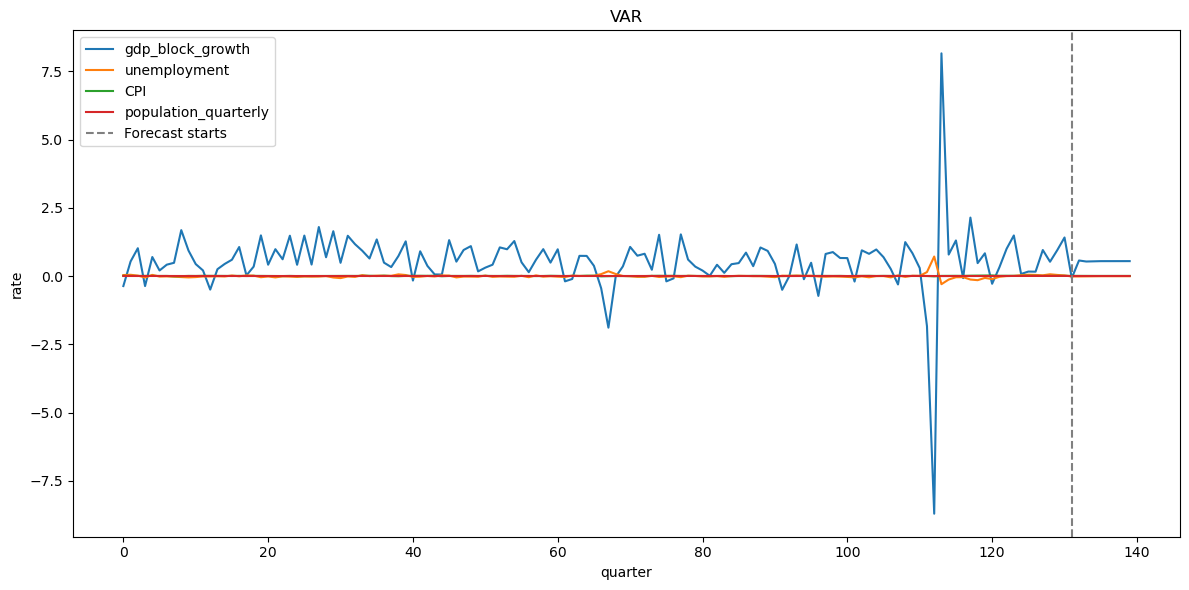

In [ ]:
import matplotlib.pyplot as plt
model = VAR(Y_use)
results = model.fit(p)


forecast_steps = 8
forecast_values = results.forecast(y=Y_use.values[-p:], steps=forecast_steps)


forecast_index = pd.RangeIndex(start=Y_use.index[-1] + 1, stop=Y_use.index[-1] + 1 + forecast_steps)
forecast_df = pd.DataFrame(forecast_values, index=forecast_index, columns=Y_use.columns)


plot_df = pd.concat([Y_use, forecast_df])


plt.figure(figsize=(12, 6))
for col in Y_use.columns:
    plt.plot(plot_df.index, plot_df[col], label=col)


plt.axvline(x=Y_use.index[-1], color='gray', linestyle='--', label='Forecast starts')


plt.title("VAR")
plt.xlabel("quarter")
plt.ylabel("rate")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
Y_use.std()

gdp_block_growth        1.215492
unemployment            0.079285
CPI                     0.004707
population_quarterly    0.001599
dtype: float64

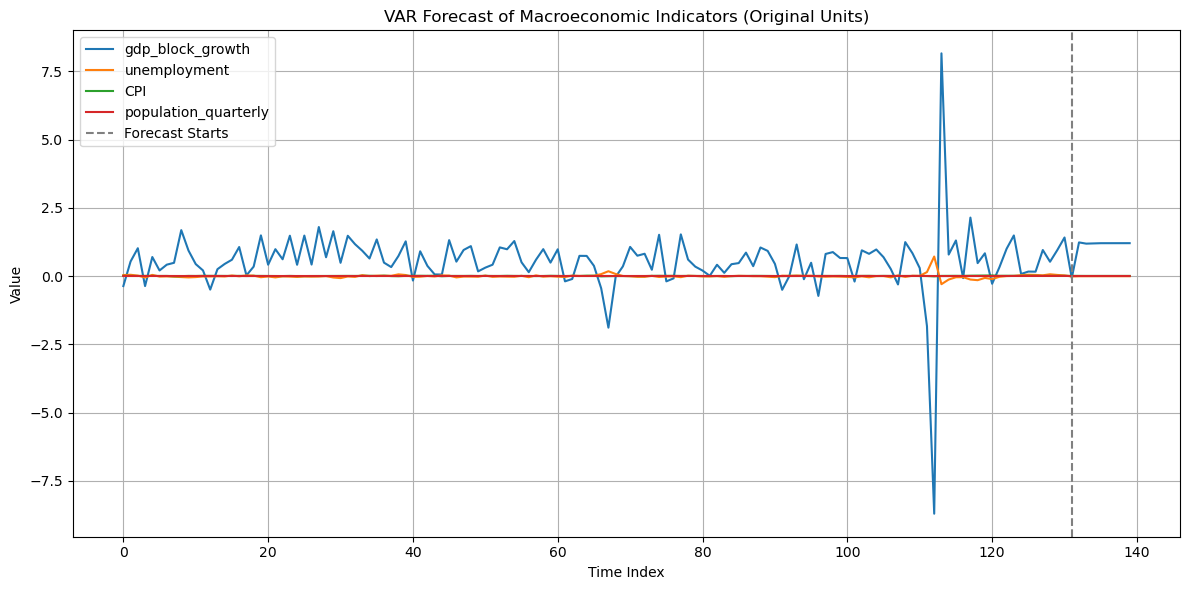

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.api import VAR

# === Step 1: Prepare the data ===
# Drop non-numeric columns (e.g., quarter)
Y_use = df_var_transformed.drop(columns=["quarter"])

# Standardize the data using training sample
scaler = StandardScaler()
Y_scaled = pd.DataFrame(
    scaler.fit_transform(Y_use),
    index=Y_use.index,
    columns=Y_use.columns
)

# === Step 2: Fit the VAR model ===
T, k = len(Y_use), Y_use.shape[1]
p_cap = max(1, min(8, int((T - 2) // (k + 1))))  # BIC cap
sel = VAR(Y_use).select_order(maxlags=p_cap)
p = int(max(1, sel.selected_orders.get("bic") or 1))  # fallback to 1

model = VAR(Y_use)
fit = model.fit(p)

# === Step 3: Forecast the next 8 quarters ===
n_forecast = 8
Y_forecast = fit.forecast(y=Y_use.values[-p:], steps=n_forecast)
Y_forecast = pd.DataFrame(Y_forecast, columns=Y_use.columns)

# === Step 4: Set index for forecast and inverse transform ===
Y_forecast.index = range(Y_use.index[-1] + 1, Y_use.index[-1] + 1 + n_forecast)
Y_forecast_unscaled = pd.DataFrame(
    scaler.inverse_transform(Y_forecast),
    index=Y_forecast.index,
    columns=Y_forecast.columns
)

# === Step 5: Combine historical + forecast (in original units) ===
combined = pd.concat([Y_use, Y_forecast_unscaled])

# === Step 6: Plot ===
plt.figure(figsize=(12, 6))
for col in combined.columns:
    plt.plot(combined.index, combined[col], label=col)

# Add vertical line at forecast start
plt.axvline(x=Y_use.index[-1], color='gray', linestyle='--', label='Forecast Starts')

# Add labels and title
plt.title("VAR Forecast of Macroeconomic Indicators (Original Units)")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
df_var.index = pd.PeriodIndex(df_var['quarter'], freq='Q')
df_var.drop(columns='quarter', inplace=True)

In [ ]:
from statsmodels.tsa.api import VAR

model = VAR(df_var)
results = model.fit(maxlags=8, ic='bic') 
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 02, Nov, 2025
Time:                     14:18:05
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    20.3578
Nobs:                     132.000    HQIC:                   20.0985
Log likelihood:          -2043.99    FPE:                4.48377e+08
AIC:                      19.9210    Det(Omega_mle):     3.86418e+08
--------------------------------------------------------------------
Results for equation gdp_block_growth
                             coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------------
const                          -4.272321         5.235706           -0.816           0.415
L1.gdp_block_growth            -0.180633         0.086126           -2.097           0.036
L1.unempl

In [66]:
forecast = results.forecast(y=df_var.values, steps=4)
forecast_df = pd.DataFrame(forecast, columns=df_var.columns)
print(forecast_df)

   gdp_block_growth  unemployment         CPI  population_quarterly
0          0.787603      6.463700  164.379509          8.351271e+07
1          0.603560      6.274046  165.602441          8.388189e+07
2          0.602857      6.118631  166.822676          8.425794e+07
3          0.576880      5.982374  168.054975          8.464020e+07


In [ ]:
future_periods = [df_var.index[-1] + i for i in range(1, 5)]
forecast_df.index = future_periods

df_forecast_full = pd.concat([df_var, forecast_df])

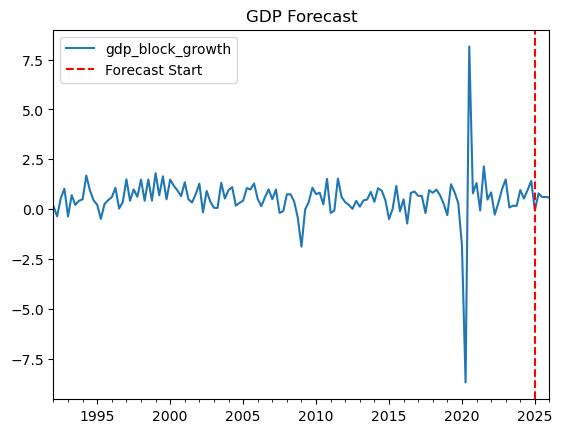

In [68]:
import matplotlib.pyplot as plt

df_forecast_full['gdp_block_growth'].plot(title='GDP Forecast')
plt.axvline(df_var.index[-1], color='r', linestyle='--', label='Forecast Start')
plt.legend()
plt.show()